LOAN DEFAULT PREDICTION MODEL
JP Morgan Quantitative Research - Task 3

[STEP 1] Loading and exploring loan data...

Dataset shape: (10000, 8)
Features: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']

Default rate: 18.51%
Total defaults: 1,851 out of 10,000 loans

Basic Statistics:
        customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count  1.000000e+04              10000.000000          10000.000000   
mean   4.974577e+06                  1.461200           4159.677034   
std    2.293890e+06                  1.743846           1421.399078   
min    1.000324e+06                  0.000000             46.783973   
25%    2.977661e+06                  0.000000           3154.235371   
50%    4.989502e+06                  1.000000           4052.377228   
75%    6.967210e+06                  2.000000           5052.898103   
max    8.999789e+06                  5.000000    

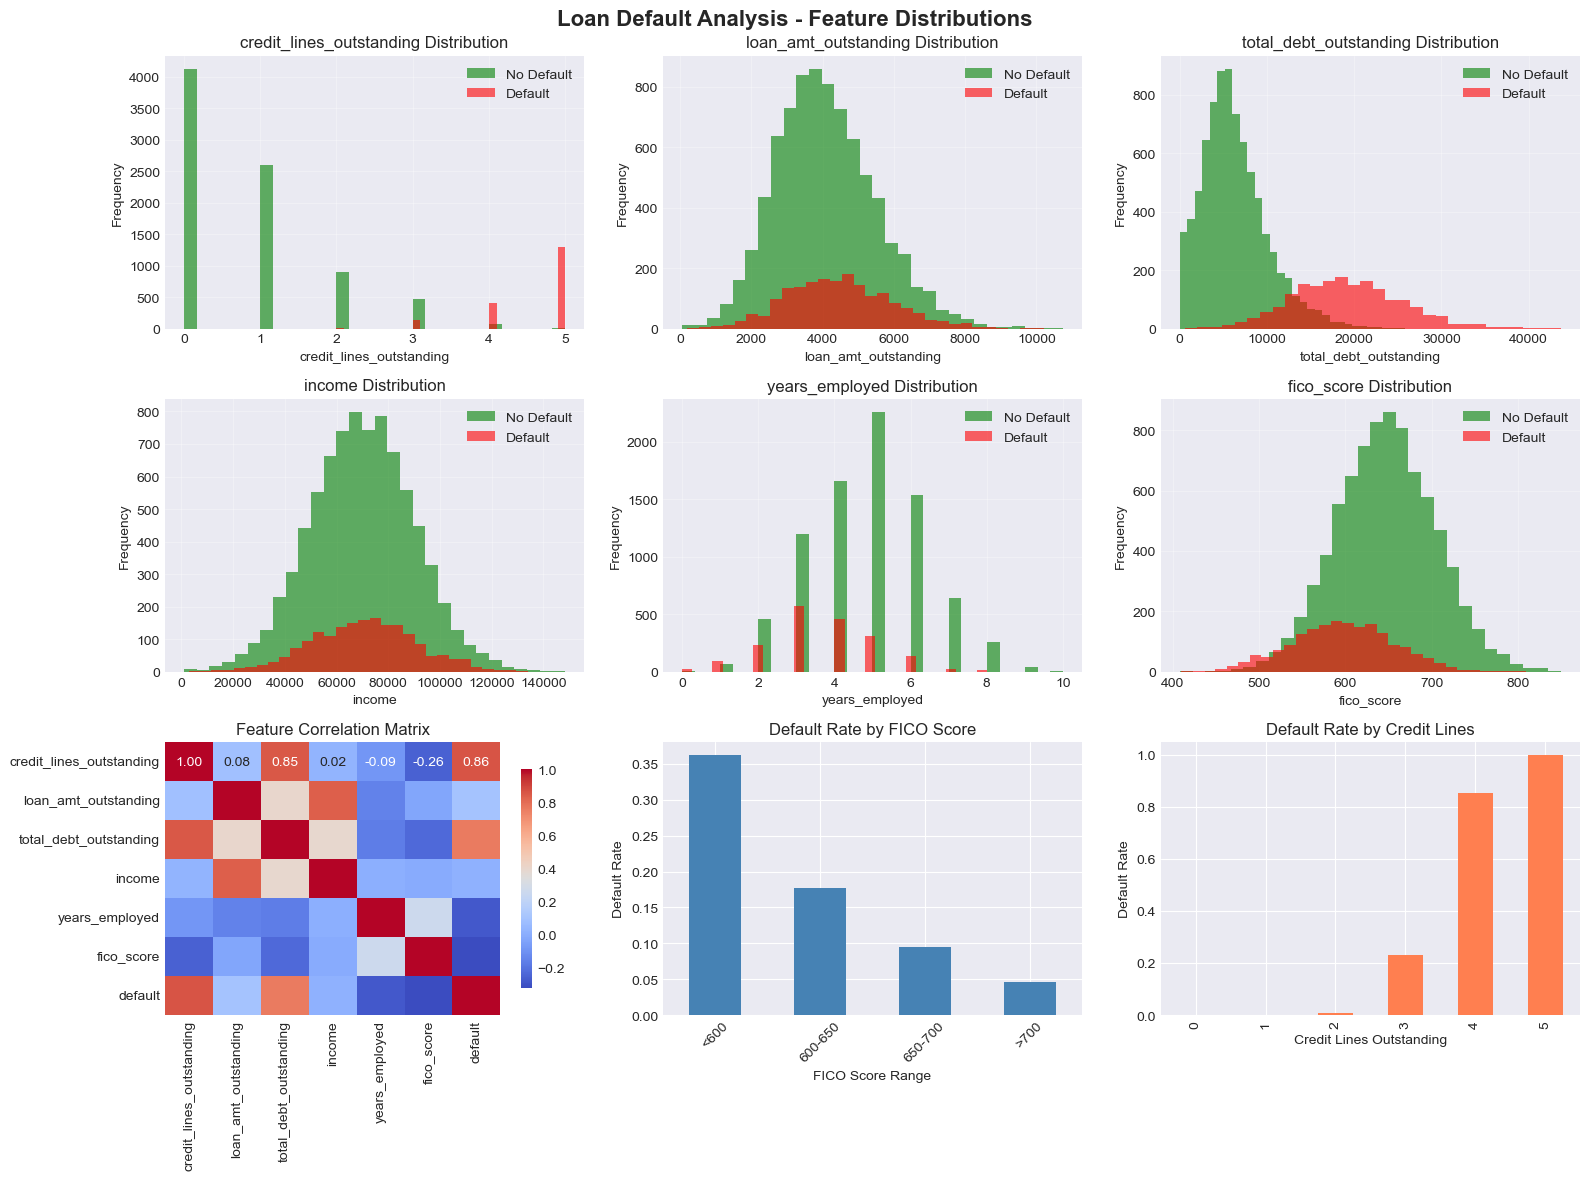

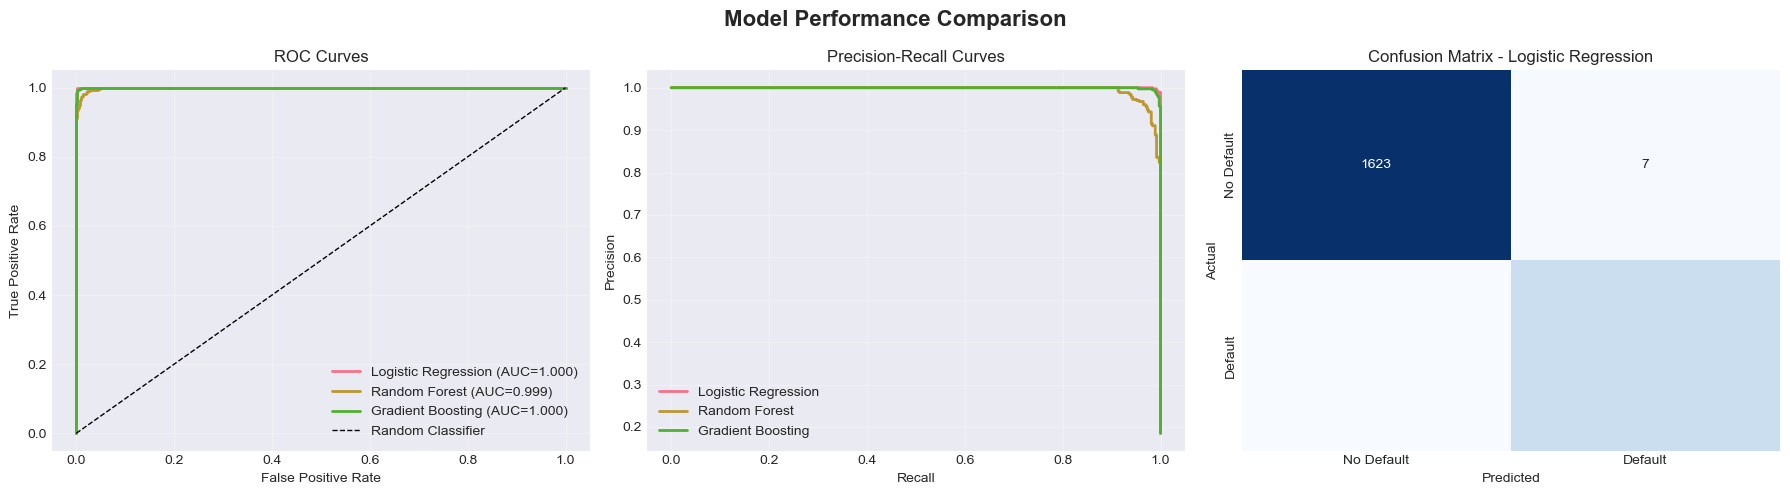

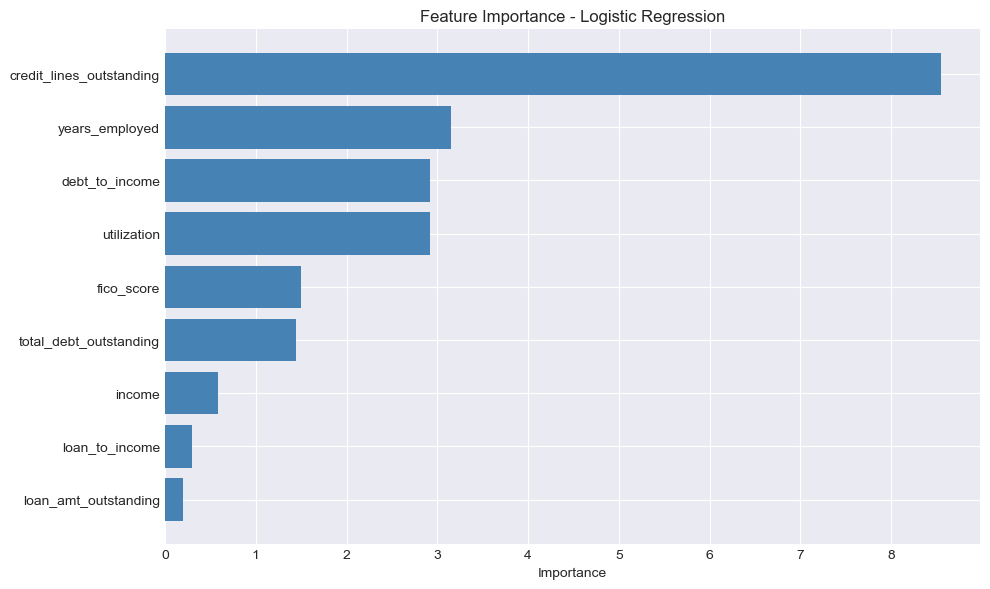

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("LOAN DEFAULT PREDICTION MODEL")
print("JP Morgan Quantitative Research - Task 3")
print("="*80)

# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================

print("\n[STEP 1] Loading and exploring loan data...")

# Load data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

print(f"\nDataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")
print(f"\nDefault rate: {df['default'].mean()*100:.2f}%")
print(f"Total defaults: {df['default'].sum():,} out of {len(df):,} loans")

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# ============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n[STEP 2] Performing exploratory data analysis...")

# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Loan Default Analysis - Feature Distributions', fontsize=16, fontweight='bold')

# Plot distributions for each feature
features = ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding',
            'income', 'years_employed', 'fico_score']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Plot distributions by default status
    df[df['default']==0][feature].hist(bins=30, alpha=0.6, label='No Default', ax=ax, color='green')
    df[df['default']==1][feature].hist(bins=30, alpha=0.6, label='Default', ax=ax, color='red')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Correlation heatmap
ax = axes[2, 0]
correlation = df.drop('customer_id', axis=1).corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')

# Default rate by FICO score bins
ax = axes[2, 1]
df['fico_bin'] = pd.cut(df['fico_score'], bins=[0, 600, 650, 700, 850], labels=['<600', '600-650', '650-700', '>700'])
default_by_fico = df.groupby('fico_bin')['default'].mean()
default_by_fico.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('FICO Score Range')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by FICO Score')
ax.tick_params(axis='x', rotation=45)

# Default rate by credit lines
ax = axes[2, 2]
default_by_credit = df.groupby('credit_lines_outstanding')['default'].mean()
default_by_credit.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Credit Lines Outstanding')
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate by Credit Lines')

plt.tight_layout()
plt.savefig('loan_default_eda.png', dpi=300, bbox_inches='tight')
print("\n✓ Exploratory visualizations saved as 'loan_default_eda.png'")

# ============================================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================================

print("\n[STEP 3] Engineering features...")

# Create a copy for modeling
df_model = df.copy()

# Drop customer_id (not predictive)
df_model = df_model.drop('customer_id', axis=1)

# Create derived features
df_model['debt_to_income'] = df_model['total_debt_outstanding'] / df_model['income']
df_model['loan_to_income'] = df_model['loan_amt_outstanding'] / df_model['income']
df_model['utilization'] = df_model['total_debt_outstanding'] / (df_model['income'] + 1)  # +1 to avoid div by zero

print(f"\nFeatures after engineering: {list(df_model.columns)}")
print(f"Total features: {len(df_model.columns) - 1}")  # -1 for target

# ============================================================================
# STEP 4: PREPARE DATA FOR MODELING
# ============================================================================

print("\n[STEP 4] Preparing data for modeling...")

# Drop fico_bin (was only for visualization) and separate features from target
df_model = df_model.drop('fico_bin', axis=1, errors='ignore')
X = df_model.drop('default', axis=1)
y = df_model['default']

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Training set default rate: {y_train.mean()*100:.2f}%")
print(f"Test set default rate: {y_test.mean()*100:.2f}%")

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# STEP 5: BUILD AND COMPARE MODELS
# ============================================================================

print("\n[STEP 5] Training multiple models...")

models = {}
predictions = {}
probabilities = {}

# Model 1: Logistic Regression
print("\n  Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
predictions['Logistic Regression'] = lr_model.predict(X_test_scaled)
probabilities['Logistic Regression'] = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
print("  Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    max_depth=10,
    min_samples_split=50,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
predictions['Random Forest'] = rf_model.predict(X_test)
probabilities['Random Forest'] = rf_model.predict_proba(X_test)[:, 1]

# Model 3: Gradient Boosting
print("  Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = gb_model.predict(X_test)
probabilities['Gradient Boosting'] = gb_model.predict_proba(X_test)[:, 1]

print("\n✓ All models trained successfully")

# ============================================================================
# STEP 6: EVALUATE MODELS
# ============================================================================

print("\n[STEP 6] Evaluating model performance...")

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

results = []

for model_name in models.keys():
    y_pred = predictions[model_name]
    y_prob = probabilities[model_name]
    
    # Calculate metrics
    auc = roc_auc_score(y_test, y_prob)
    
    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        'Model': model_name,
        'AUC-ROC': auc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score']
    })
    
    print(f"\n{model_name}:")
    print(f"  AUC-ROC Score: {auc:.4f}")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall: {report['1']['recall']:.4f}")
    print(f"  F1-Score: {report['1']['f1-score']:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"\n✓ Best Model: {best_model_name} (AUC-ROC: {results_df['AUC-ROC'].max():.4f})")

# ============================================================================
# STEP 7: VISUALIZE MODEL PERFORMANCE
# ============================================================================

print("\n[STEP 7] Creating performance visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Plot 1: ROC Curves
ax = axes[0]
for model_name in models.keys():
    y_prob = probabilities[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curves
ax = axes[1]
for model_name in models.keys():
    y_prob = probabilities[model_name]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(recall, precision, label=model_name, linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix for best model
ax = axes[2]
cm = confusion_matrix(y_test, predictions[best_model_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')
print("✓ Performance visualizations saved as 'model_performance.png'")

# ============================================================================
# STEP 8: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n[STEP 8] Analyzing feature importance...")

# Get feature importance from best model
if best_model_name == 'Logistic Regression':
    # For logistic regression, use coefficients
    importance = np.abs(best_model.coef_[0])
    feature_names = X.columns
else:
    # For tree-based models, use feature_importances_
    importance = best_model.feature_importances_
    feature_names = X.columns

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(importance_df.head().to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title(f'Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Feature importance visualization saved as 'feature_importance.png'")

# ============================================================================
# STEP 9: CREATE EXPECTED LOSS PREDICTION FUNCTION
# ============================================================================

print("\n[STEP 9] Creating expected loss prediction function...")

# Recovery rate provided in task
RECOVERY_RATE = 0.10
LOSS_GIVEN_DEFAULT = 1 - RECOVERY_RATE  # 0.90

def predict_expected_loss(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score
):
    """
    Predict the expected loss for a loan based on borrower characteristics.
    
    This function estimates the probability of default using the trained model
    and calculates the expected loss assuming a 10% recovery rate.
    
    Parameters:
    -----------
    credit_lines_outstanding : int
        Number of other credit lines the borrower has (0-5)
    loan_amt_outstanding : float
        Current loan amount in dollars
    total_debt_outstanding : float
        Total debt outstanding across all loans in dollars
    income : float
        Annual income in dollars
    years_employed : int
        Years at current employment
    fico_score : int
        Credit score (300-850)
    
    Returns:
    --------
    dict
        Dictionary containing:
        - 'probability_of_default': Estimated probability (0-1)
        - 'expected_loss': Expected loss in dollars
        - 'loan_amount': Input loan amount
        - 'risk_rating': Risk category (Low/Medium/High)
    
    Formula:
    --------
    Expected Loss = PD × EAD × LGD
    where:
        PD = Probability of Default (model prediction)
        EAD = Exposure at Default (loan_amt_outstanding)
        LGD = Loss Given Default (0.90, assuming 10% recovery)
    
    Example:
    --------
    >>> result = predict_expected_loss(
    ...     credit_lines_outstanding=2,
    ...     loan_amt_outstanding=5000,
    ...     total_debt_outstanding=8000,
    ...     income=60000,
    ...     years_employed=4,
    ...     fico_score=650
    ... )
    >>> print(f"Expected Loss: ${result['expected_loss']:.2f}")
    """
    
    # Create input DataFrame with same structure as training data
    input_data = pd.DataFrame({
        'credit_lines_outstanding': [credit_lines_outstanding],
        'loan_amt_outstanding': [loan_amt_outstanding],
        'total_debt_outstanding': [total_debt_outstanding],
        'income': [income],
        'years_employed': [years_employed],
        'fico_score': [fico_score]
    })
    
    # Calculate derived features (same as training)
    input_data['debt_to_income'] = input_data['total_debt_outstanding'] / input_data['income']
    input_data['loan_to_income'] = input_data['loan_amt_outstanding'] / input_data['income']
    input_data['utilization'] = input_data['total_debt_outstanding'] / (input_data['income'] + 1)
    
    # Predict probability of default using the best model
    if best_model_name == 'Logistic Regression':
        # Scale features for logistic regression
        input_scaled = scaler.transform(input_data)
        probability_of_default = best_model.predict_proba(input_scaled)[0, 1]
    else:
        # Tree-based models don't need scaling
        probability_of_default = best_model.predict_proba(input_data)[0, 1]
    
    # Calculate expected loss
    # Expected Loss = PD × EAD × LGD
    expected_loss = probability_of_default * loan_amt_outstanding * LOSS_GIVEN_DEFAULT
    
    # Assign risk rating
    if probability_of_default < 0.10:
        risk_rating = 'Low'
    elif probability_of_default < 0.25:
        risk_rating = 'Medium'
    else:
        risk_rating = 'High'
    
    return {
        'probability_of_default': probability_of_default,
        'expected_loss': expected_loss,
        'loan_amount': loan_amt_outstanding,
        'risk_rating': risk_rating
    }

print("✓ Expected loss prediction function created successfully")

# ============================================================================
# STEP 10: TEST THE FUNCTION WITH EXAMPLES
# ============================================================================

print("\n[STEP 10] Testing prediction function with sample cases...")

print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Test Case 1: Low risk borrower
print("\nTest Case 1: Low Risk Borrower")
print("-" * 40)
result1 = predict_expected_loss(
    credit_lines_outstanding=0,
    loan_amt_outstanding=5000,
    total_debt_outstanding=3000,
    income=80000,
    years_employed=5,
    fico_score=720
)
print(f"FICO Score: 720 (High)")
print(f"Income: $80,000")
print(f"Loan Amount: ${result1['loan_amount']:,.2f}")
print(f"Probability of Default: {result1['probability_of_default']*100:.2f}%")
print(f"Expected Loss: ${result1['expected_loss']:,.2f}")
print(f"Risk Rating: {result1['risk_rating']}")

# Test Case 2: Medium risk borrower
print("\nTest Case 2: Medium Risk Borrower")
print("-" * 40)
result2 = predict_expected_loss(
    credit_lines_outstanding=2,
    loan_amt_outstanding=5000,
    total_debt_outstanding=8000,
    income=50000,
    years_employed=3,
    fico_score=620
)
print(f"FICO Score: 620 (Medium)")
print(f"Income: $50,000")
print(f"Loan Amount: ${result2['loan_amount']:,.2f}")
print(f"Probability of Default: {result2['probability_of_default']*100:.2f}%")
print(f"Expected Loss: ${result2['expected_loss']:,.2f}")
print(f"Risk Rating: {result2['risk_rating']}")

# Test Case 3: High risk borrower
print("\nTest Case 3: High Risk Borrower")
print("-" * 40)
result3 = predict_expected_loss(
    credit_lines_outstanding=5,
    loan_amt_outstanding=5000,
    total_debt_outstanding=18000,
    income=30000,
    years_employed=1,
    fico_score=540
)
print(f"FICO Score: 540 (Low)")
print(f"Income: $30,000")
print(f"Loan Amount: ${result3['loan_amount']:,.2f}")
print(f"Probability of Default: {result3['probability_of_default']*100:.2f}%")
print(f"Expected Loss: ${result3['expected_loss']:,.2f}")
print(f"Risk Rating: {result3['risk_rating']}")

# ============================================================================
# STEP 11: PORTFOLIO ANALYSIS
# ============================================================================

print("\n[STEP 11] Calculating total portfolio expected loss...")

# Apply model to entire test set
if best_model_name == 'Logistic Regression':
    test_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    test_probabilities = best_model.predict_proba(X_test)[:, 1]

# Get loan amounts from test set
test_loan_amounts = X_test['loan_amt_outstanding'].values

# Calculate expected losses
test_expected_losses = test_probabilities * test_loan_amounts * LOSS_GIVEN_DEFAULT

# Create summary
print("\n" + "="*80)
print("PORTFOLIO EXPECTED LOSS ANALYSIS")
print("="*80)
print(f"\nTest Portfolio Size: {len(X_test):,} loans")
print(f"Total Loan Amount: ${test_loan_amounts.sum():,.2f}")
print(f"Average Loan Amount: ${test_loan_amounts.mean():,.2f}")
print(f"\nTotal Expected Loss: ${test_expected_losses.sum():,.2f}")
print(f"Average Expected Loss per Loan: ${test_expected_losses.mean():,.2f}")
print(f"Expected Loss Rate: {(test_expected_losses.sum() / test_loan_amounts.sum())*100:.2f}%")

# Risk segmentation
risk_segments = pd.DataFrame({
    'Probability_of_Default': test_probabilities,
    'Loan_Amount': test_loan_amounts,
    'Expected_Loss': test_expected_losses
})

risk_segments['Risk_Category'] = pd.cut(
    risk_segments['Probability_of_Default'],
    bins=[0, 0.10, 0.25, 1.0],
    labels=['Low', 'Medium', 'High']
)

print("\n" + "="*80)
print("RISK SEGMENTATION")
print("="*80)
segment_summary = risk_segments.groupby('Risk_Category').agg({
    'Loan_Amount': ['count', 'sum', 'mean'],
    'Expected_Loss': ['sum', 'mean'],
    'Probability_of_Default': 'mean'
}).round(2)

print(segment_summary)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("MODEL DEPLOYMENT SUMMARY")
print("="*80)

print(f"""
 MODEL DETAILS:
  • Best Model: {best_model_name}
  • AUC-ROC Score: {results_df['AUC-ROC'].max():.4f}
  • Training Data: {len(X_train):,} loans
  • Test Data: {len(X_test):,} loans

 KEY INSIGHTS:
  • Default Rate: {df['default'].mean()*100:.2f}%
  • Recovery Rate: {RECOVERY_RATE*100:.0f}%
  • Loss Given Default: {LOSS_GIVEN_DEFAULT*100:.0f}%

 PORTFOLIO METRICS:
  • Total Expected Loss: ${test_expected_losses.sum():,.2f}
  • Expected Loss Rate: {(test_expected_losses.sum() / test_loan_amounts.sum())*100:.2f}%
  
 FUNCTION AVAILABLE:
  predict_expected_loss(credit_lines, loan_amt, total_debt, income, years_employed, fico)
  
 OUTPUT FILES:
  • loan_default_eda.png - Exploratory analysis
  • model_performance.png - Model comparison
  • feature_importance.png - Key risk drivers
""")

print("="*80)
print("MODEL READY FOR DEPLOYMENT TO RISK TEAM")
print("="*80)